### Importing the libraries

In [63]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from altair import data_transformers
from tqdm import tqdm
import torch.nn.functional as F
from xgboost.testing import data_dir
import xgboost as xgb

### Root data directory path

In [64]:
data_dir =(r"C:\Users\sandy\IdeaProjects\SignatureRecognition\notebook\Data")

### Total number of classes

In [65]:
class_name = os.listdir(data_dir)
len(class_name)

2

In [66]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms as T, datasets

### Checking cuda availability

In [67]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:{}".format(device))

Device:cpu


### Transforming the data

In [69]:
data_transformer = T.Compose([
    T.Resize(size=(224,224)), #Resizing the image by 224 by 224
    T.RandomRotation(degrees=(-20, +20)), #Randomly rotating the image by 20 degrees
    T.ToTensor(), #Converting the image to tensor
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [70]:
data = datasets.ImageFolder(data_dir, transform=data_transformer)
total_count = len(data)

In [71]:
total_count

2640

In [72]:
data.classes

['Forged', 'Original']

#### Splitting the data

In [27]:
train_count = int(0.6 * total_count)
valid_count = int(0.3 * total_count)
test_count = total_count - train_count - valid_count
train_data, val_data, test_data = torch.utils.data.random_split(data, [train_count, valid_count, test_count])

In [28]:
train_data.dataset

Dataset ImageFolder
    Number of datapoints: 2640
    Root location: C:\Users\sandy\IdeaProjects\SignatureRecognition\notebook\Data
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [29]:
len(train_data.indices)

1584

In [30]:
len(test_data.indices)

264

In [31]:
len(val_data.indices)

792

### Defining some function

In [36]:
def show_image(image, label, get_denormalize = True):

    image = image.permute(1, 2, 0)
    mean = torch.FloatTensor([0.485, 0.456, 0.406])
    std = torch.FloatTensor([0.229, 0.224, 0.225])

    if get_denormalize == True:
        image = image * std + mean
        image = np.clip(image, 0, 1)
        plt.imshow(image)
        plt.title(label)
    else:
        plt.imshow(image)
        plt.title(label)

def show_grid(image, title=None):

    image = image.permute(1, 2, 0)
    mean = torch.FloatTensor([0.485, 0.456, 0.406])
    std = torch.FloatTensor([0.229, 0.224, 0.225])

    image = image*std + mean
    image = np.clip(image, 0, 1)

    plt.figure(figsize= [15, 15])
    plt.imshow(image)

    if title !=None:
        plt.title(title)

def accuracy(y_pred, y_true):
    y_pred = F.softmax(y_pred, dim=1)
    top_p, top_class = y_pred.topk(1, dim=1)
    equals = top_class == y_true.view(*top_class.shape)
    return torch.mean(equals.type(torch.FloatTensor))

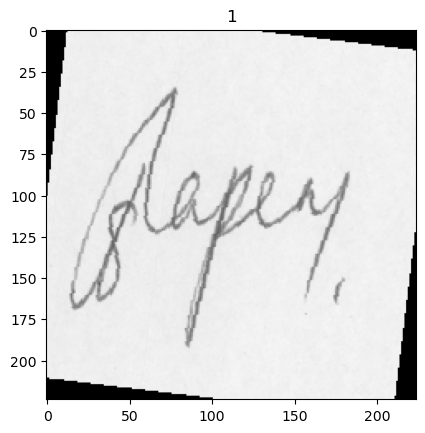

In [37]:
img, label = train_data[0]
show_image(img, label)

#### Data Loader

In [42]:
trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
print("No of batches in trainloader:{}".format(len(trainloader)))
print("No of Total examples:{}".format(len(trainloader.dataset)))

validationloader = DataLoader(val_data, batch_size=32, shuffle=True)
print("No of batches in validationloader:{}".format(len(validationloader)))
print("No of Total examples:{}".format(len(validationloader.dataset)))

testloader = DataLoader(test_data, batch_size=32, shuffle=False)
print("No of batches in testloader:{}".format(len(testloader)))
print("No of Total example:{}".format(len(testloader.dataset)))

No of batches in trainloader:50
No of Total examples:1584
No of batches in validationloader:25
No of Total examples:792
No of batches in testloader:9
No of Total example:264


### Model

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
import torchvision.transforms as transforms

In [46]:
model = models.resnet34(pretrained=True)

In [78]:
model.fc = nn.Sequential(
    nn.Dropout(0.1),
    nn.LazyLinear( len(class_name)) # Automatically detects num_ftrs
)
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

In [79]:
def train(model, criterion, optimizer, train_dataloader, test_dataloader):

    total_train_loss = 0
    total_test_loss = 0

    model.train()
    with tqdm(train_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'training')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)
            output = model(images)

            loss = criterion(output, idxs)
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

    model.eval()
    with tqdm(test_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'testing')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)

            output = model(images)
            loss = criterion(output, idxs)
            total_test_loss += loss.item()

    train_acc = total_train_loss / len(train_data)
    test_acc = total_test_loss / len(val_data)
    print(f'Train loss: {train_acc:.4f} Test loss: {test_acc:.4f} ')

In [80]:
%%time
epochs=5
for i in range(epochs):
    print(f"Epoch {i+1}/{epochs}")
    train(model, criterion, optimizer, trainloader, validationloader)

Epoch 1/5


Train loss: 0.0077 Test loss: 0.0217 
Epoch 2/5


Train loss: 0.0006 Test loss: 0.0001 
Epoch 3/5


Train loss: 0.0006 Test loss: 0.0009 
Epoch 4/5


Train loss: 0.0002 Test loss: 0.0000 
Epoch 5/5


Train loss: 0.0002 Test loss: 0.0001 
CPU times: total: 2h 22min 27s
Wall time: 6min 31s


#### Model saving

In [84]:
path =r'C:\\Users\\sandy\\IdeaProjects\\SignatureRecognition\\notebook\\model.pt'
torch.save(model, path)

In [81]:
pwd

'C:\\Users\\sandy\\IdeaProjects\\SignatureRecognition\\notebook'

#### Loading torch model

In [95]:
#Model class must be defne somewhere
model = torch.load(path, weights_only=False)


In [96]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

### Model Evaluation

In [97]:
def evaluate(model, criterion, optimizer, test_dataloader):
    total_test_loss = 0

    model.eval()
    with tqdm(test_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'testing')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)

            output = model(images)
            loss = criterion(output, idxs)
            total_test_loss += loss.item()

    test_acc = total_test_loss / len(val_data)
    print(f'Test loss: {test_acc:.4f} ')

In [98]:
evaluate(model, criterion, optimizer, testloader)

Test loss: 0.0000 


### Prediction

In [100]:
label_names = data.classes
label_names

['Forged', 'Original']

In [102]:
from PIL import Image

# Load the image and preprocess it
image = Image.open(r'C:\Users\sandy\IdeaProjects\SignatureRecognition\notebook\Data\Original\original_1_1.png')
preprocess = transforms.Compose([
    transforms.Resize(size = (224,224)),
    transforms.Grayscale(3),
    transforms.ToTensor()
])

image = preprocess(image)
image  = image[:3]

# Convert the image to a PyTorch tensor and send it to the device
image = image.unsqueeze(0).to(device)

# Make the prediction
with torch.no_grad():
    logits = model(image)
    probs = torch.softmax(logits, dim=1)
    pred_label = torch.argmax(probs, dim=1)

# Print the prediction
print(f'Predicted label: {pred_label.item()}')

# Map the predicted label to the corresponding class name
predicted_class_name = label_names[pred_label.item()]

# Print the predicted class name
print(f'Predicted class name: {predicted_class_name}')

Predicted label: 1
Predicted class name: Original
